<a href="https://colab.research.google.com/github/AlexanderEgorovNRNUMEPHI/AIM-projects/blob/main/DL/HW4/HW4_ML3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torchvision.transforms as transforms
import torchvision.datasets   as datasets
import torch.nn.functional    as F
import torchvision.models     as models

import matplotlib.pyplot      as plt
import torch.optim            as optim
import torch.nn               as nn

import torchvision
import colorsys
import random
import torch
import json
import time
import tqdm
import cv2
import os

from torchvision.transforms.functional import convert_image_dtype, resize
from torch.utils.data   import DataLoader
from collections        import namedtuple
from matplotlib.patches import Polygon
from matplotlib         import patches, lines
from PIL                import Image

from torchvision.io import read_image
from string import digits, ascii_uppercase

import albumentations as alb
import numpy          as np
import scipy          as sp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [ ]:
PATH_TO_DATA = ".\\data\\car_license"  # Change to your path with unzipped data

In [ ]:
train_path_complex = os.path.join(PATH_TO_DATA, "train\\train\\complex")
train_path_simple = os.path.join(PATH_TO_DATA, "train\\train\\simple")
test_path = os.path.join(PATH_TO_DATA, "test\\result\\")

def get_config(path):
    config_full_paths = []
    for imagename in os.listdir(path):
        config_full_paths.append({"file": os.path.join(path, imagename),
                                  "text": imagename[:-4].split("_")[-1]})
    return config_full_paths




config_simple = get_config(train_path_simple)
config_complex = get_config(train_path_complex)


In [ ]:
config_test = get_config(test_path)

config_test = sorted(config_test, key=lambda d: int(d['text']))

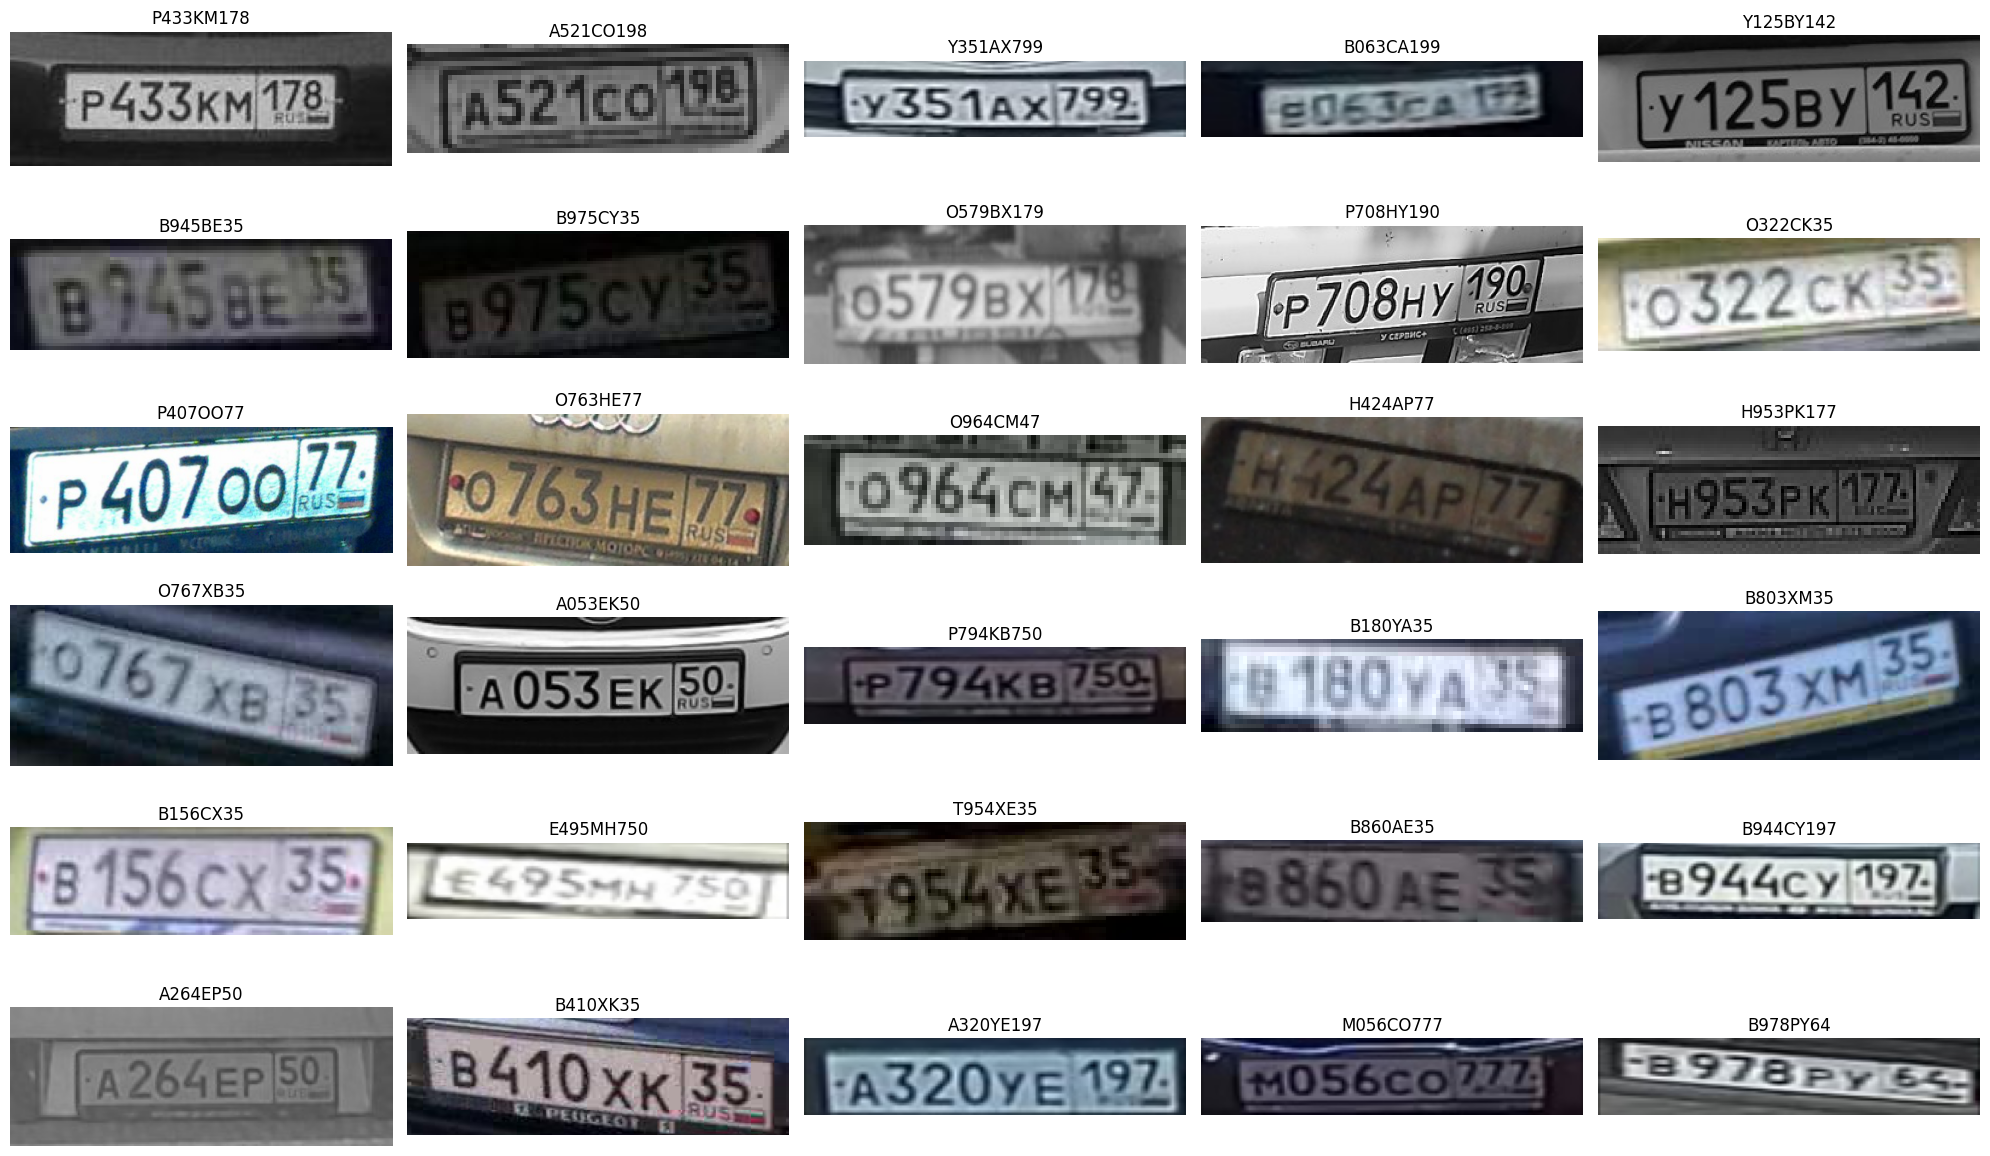

In [ ]:
SAMPLE_SIZE = 30
NUM_COLS = 5
NUM_ROWS = SAMPLE_SIZE // NUM_COLS + int(SAMPLE_SIZE % NUM_COLS != 0)

random_idxs = np.random.choice(len(config_complex), size=SAMPLE_SIZE, replace=False)
plt.figure(figsize=(20, 2 * NUM_ROWS))
for i, idx in enumerate(random_idxs, 1):
    item = config_complex[idx]
    text = item["text"]
    image = cv2.imread(item["file"])

    plt.subplot(NUM_ROWS, NUM_COLS, i)
    plt.imshow(image[:, :, ::-1])
    plt.title(text)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
abc = "0123456789ABEKMHOPCTYX"  # this is our alphabet for predictions.

In [ ]:
def compute_mask(text):
    """Compute letter-digit mask of text, e.g. 'E506EC152' -> 'LDDDLLDDD'.

    Args:
        - text: String of text.

    Returns:
        String of the same length but with every letter replaced by 'L' and every digit replaced by 'D'
        or None if non-letter and non-digit character met in text.
    """
    mask = []

    # YOUR CODE HERE
    for char in text:
        if char in digits:
            mask.append("D")
        elif char in ascii_uppercase:
            mask.append("L")
        else:
            return None
    # END OF YOUR CODE

    return "".join(mask)

assert compute_mask("E506EC152") == "LDDDLLDDD"
assert compute_mask("E123KX99" ) == "LDDDLLDD"
assert compute_mask("P@@@KA@@" ) is None

In [ ]:
def check_in_alphabet(text, alphabet=abc):
    """Check if all chars in text come from alphabet.

    Args:
        - text: String of text.
        - alphabet: String of alphabet.

    Returns:
        True if all chars in text are from alphabet and False otherwise.
    """

    # YOUR CODE HERE
    for char in text:
        if char not in alphabet:
            return False
    # END OF YOUR CODE

    return True

assert check_in_alphabet("E506EC152") is True
assert check_in_alphabet("A123GG999") is False

In [ ]:
def filter_data(config):
    """Filter config items keeping only ones with correct text.

    Args:
        - config: List of dicts, each dict having keys "file" and "text".

    Returns:
        Filtered list (config subset).
    """
    config_filtered = []
    for item in tqdm.tqdm(config):
        text = item["text"]
        mask = compute_mask(text)
        if check_in_alphabet(text) and (mask == "LDDDLLDD" or mask == "LDDDLLDDD"):
            config_filtered.append({"file": item["file"], "text": item["text"]})
    return config_filtered

In [ ]:
print("Total items in data complex before filtering:", len(config_complex))
config_complex = filter_data(config_complex)
print("Total items in data complex after filtering:", len(config_complex))


print("Total items in data simple before filtering:", len(config_simple))
config_simple = filter_data(config_simple)
print("Total items in data simple after filtering:", len(config_simple))

Total items in data complex before filtering: 14221


100%|████████████████████████████████████████████████████████████████████████████| 14221/14221 [00:00<00:00, 310908.62it/s]


Total items in data complex after filtering: 14221
Total items in data simple before filtering: 10326


100%|████████████████████████████████████████████████████████████████████████████| 10326/10326 [00:00<00:00, 348818.76it/s]

Total items in data simple after filtering: 10326


In [ ]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class RecognitionDataset(Dataset):
    """Class for training image-to-text mapping using CTC-Loss."""

    def __init__(self, config, alphabet=abc, transforms=None):
        """Constructor for class.

        Args:
            - config: List of items, each of which is a dict with keys "file" & "text".
            - alphabet: String of chars required for predicting.
            - transforms: Transformation for items, should accept and return dict with keys "image", "seq", "seq_len" & "text".
        """
        super(RecognitionDataset, self).__init__()
        self.config                  = config
        self.alphabet                = alphabet
        self.image_names, self.texts = self._parse_root_()
        self.transforms              = transforms

    def _parse_root_(self):
        image_names, texts = [], []
        for item in self.config:
            image_name = item["file"]
            text = item['text']
            texts.append(text)
            image_names.append(image_name)
        return image_names, texts

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        """Returns dict with keys "torch_image", "pil_image", "seq", "seq_len" & "text".
        Image is a numpy array, float32, [0, 1].
        Seq is list of integers.
        Seq_len is an integer.
        Text is a string.
        """
        pil_image   = Image.open(self.image_names[item]).convert('RGB')
        torch_image = self.transforms(pil_image)

        text    = self.texts[item]
        seq     = self.text_to_seq(text)
        seq_len = len(seq)
        output  = dict(torch_image=torch_image, pil_image=pil_image, seq=seq, seq_len=seq_len, text=text)

        return output

    def text_to_seq(self, text):
        """Encode text to sequence of integers.

        Args:
            - String of text.

        Returns:
            List of integers where each number is index of corresponding characted in alphabet + 1.
        """

        # YOUR CODE HERE
        seq = [self.alphabet.find(c) + 1 for c in text]
        # END OF YOUR CODE

        return seq

In [ ]:
from torchvision.transforms.v2 import Compose, Resize, ToDtype, ToImage, Normalize, RandomRotation, RandomPerspective, GaussianBlur, ColorJitter

# ToImage - преобразование в тензор
# ToDtype - преобразование типа тензора
# Resize  - интерполяция тензора к требуемому размеру

transforms = Compose([
    ToImage(), ToDtype(torch.float32, scale=True), Resize(size=(32,160)),
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transforms_train = Compose([
    ToImage(), ToDtype(torch.float32, scale=True), Resize(size=(32,160)),
    RandomRotation(10),
    RandomPerspective(distortion_scale=0.5, p=0.5),
    ColorJitter(brightness=.5, hue=.3),
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


dataset_complex = RecognitionDataset(config_complex, alphabet=abc, transforms=transforms_train)
dataset_simple = RecognitionDataset(config_simple, alphabet=abc, transforms=transforms_train)

In [ ]:
from torchvision.transforms.functional import to_pil_image
x = dataset_complex[0]
print("Image shape:", x["torch_image"].shape)
print("Seq:" , x["seq"], "Seq_len:", x["seq_len"])
print("Text:", x["text"])

Image shape: torch.Size([3, 32, 160])
Seq: [13, 1, 4, 2, 19, 15, 8, 8, 8] Seq_len: 9
Text: E031CM777


In [ ]:
def collate_fn(batch):
    """Function for torch.utils.data.Dataloader for batch collecting.

    Args:
        - batch: List of dataset __getitem__ return values (dicts).

    Returns:
        Dict with same keys but values are either torch.Tensors of batched images or sequences or so.
    """
    torch_images, pil_images, seqs, seq_lens, texts = [], [], [], [], []
    # YOUR CODE HERE
    for item in batch:
        torch_images.append(item["torch_image"]  )
        pil_images  .append(item["pil_image"  ]  )
        seqs        .extend(item["seq"        ]  )
        seq_lens    .append(item["seq_len"    ]  )
        texts       .append(item["text"       ]  )
    torch_images = torch.stack(torch_images)
    pil_images   = pil_images
    seqs         = torch.Tensor(seqs    ).int()
    seq_lens     = torch.Tensor(seq_lens).int()
    # END OF YOUR CODE
    return {"torch_images": torch_images, "pil_images":pil_images, "seq": seqs, "seq_len": seq_lens, "text": texts}

In [ ]:
xs = [dataset_complex[i] for i in range(4)]
batch = collate_fn(xs)
print(batch.keys())

dict_keys(['torch_images', 'pil_images', 'seq', 'seq_len', 'text'])


In [ ]:
print("Tensor:" , batch["torch_images"].size())
print("Seq:"    , batch["seq"         ].size())
print("Seq:"    , batch["seq"         ])
print("Seq_len:", batch["seq_len"     ])
print("Text:"   , batch["text"        ])

Tensor: torch.Size([4, 3, 32, 160])
Seq: torch.Size([35])
Seq: tensor([13,  1,  4,  2, 19, 15,  8,  8,  8, 12, 10,  8,  4, 14, 13,  4,  6, 16,
         8,  2, 10, 11, 17,  2, 10,  8, 18,  1,  3,  9, 13, 14,  8,  8,  8],
       dtype=torch.int32)
Seq_len: tensor([9, 8, 9, 9], dtype=torch.int32)
Text: ['E031CM777', 'B973KE35', 'H719AO197', 'P028EK777']


In [ ]:
from torch.nn  import Module, GRU, LSTM, Sequential, Conv2d, Linear

class FeatureExtractor(nn.Module):
    def __init__(self, imgH, leakyRelu=False, PRelu=False):
        super(FeatureExtractor, self).__init__()
        assert imgH % 16 == 0, 'imgH has to be a multiple of 16'

        # YOUR CODE HERE
        ks = [3, 3, 3, 3, 3, 3, 2]
        ps = [1, 1, 1, 1, 1, 1, 0]
        ss = [1, 1, 1, 1, 1, 1, 1]
        nm = [64, 128, 256, 256, 512, 512, 512]

        cnn = nn.Sequential()

        def convRelu(i, batchNormalization=False):
            nIn = 3 if i == 0 else nm[i - 1]
            nOut = nm[i]
            cnn.add_module('conv{0}'.format(i), nn.Conv2d(nIn, nOut, ks[i], ss[i], ps[i]))
            if batchNormalization:
                cnn.add_module('batchnorm{0}'.format(i), nn.BatchNorm2d(nOut))
            if leakyRelu:
                cnn.add_module('relu{0}'.format(i), nn.LeakyReLU(0.2, inplace=True))
            elif PRelu:
                cnn.add_module('relu{0}'.format(i), nn.PReLU())
            else:
                cnn.add_module('relu{0}'.format(i), nn.ReLU(True))

        convRelu(0)
        cnn.add_module('pooling{0}'.format(0), nn.MaxPool2d(2, 2))  # 64x16x64
        convRelu(1)
        cnn.add_module('pooling{0}'.format(1), nn.MaxPool2d(2, 2))  # 128x8x32
        convRelu(2, True)
        convRelu(3)
        cnn.add_module('pooling{0}'.format(2), nn.MaxPool2d((2, 2), (2, 1), (0, 1)))  # 256x4x16
        convRelu(4, True)
        convRelu(5)
        cnn.add_module('pooling{0}'.format(3), nn.MaxPool2d((2, 2), (2, 1), (0, 1)))  # 512x2x16
        convRelu(6, True)  # 512x1x16

        # END OF YOUR CODE
        self.cnn = cnn

    def forward(self, input):
        conv = self.cnn( input )

        b, c, h, w = conv.size()
        conv   = conv.squeeze(2      )
        output = conv.permute(2, 0, 1)  # [w, b, c]

        return output

In [ ]:
nclass     = len(abc) + 1
imgH, imgW = 32, 160
nc, nh     = 3 , 512
nl         = 1

In [ ]:
x = torch.randn(1, 3, 32, 160)
y = FeatureExtractor(imgH, leakyRelu=False, PRelu=False)(x)

assert y.size() == (41, 1, 512)

In [ ]:
class BidirectionalLSTM(nn.Module):
    def __init__(self, nL, nIn, nHidden):
        super(BidirectionalLSTM, self).__init__()
        # YOUR CODE HERE
        self.rnn       = nn.LSTM(nIn, nHidden, num_layers=nL, bidirectional=True)
        # END OF YOUR CODE
    def forward(self, input):
        recurrent, _ = self.rnn(input)
        return recurrent

In [ ]:
class Encoder(nn.Module):
    def __init__(self, imgH, nh, leakyRelu=False, PRelu=False):
        super(Encoder, self).__init__()
        self.cnn = FeatureExtractor(imgH, leakyRelu=False, PRelu=False)
    def forward(self, input):
        # conv features
        return self.cnn(input)

class Decoder(nn.Module):
    def __init__(self, nl, nh):
        super(Decoder, self).__init__()

        #self.rnn_s_1 = BidirectionalLSTM(nl, nh, 256)
        self.rnn_s = BidirectionalLSTM(nl, nh, nh)
    def forward(self, input):
        #output = self.rnn_s_1(input)
        output = self.rnn_s(input)
        return output

In [ ]:
x = torch.randn(1, 3, 32, 160)
y = Encoder(imgH, nh, leakyRelu=False, PRelu=False)(x)

assert y.size() == (41, 1, 512) #(sequence_size, batch_size, feature_size)

In [ ]:
class ConvolutionalRecurrentNeuralNetwork(Module):
    def __init__(self, imgH, nl, nh, nclass, leakyRelu=False, PRelu=False):
        super(ConvolutionalRecurrentNeuralNetwork, self).__init__()
        self.encoder    = Encoder(imgH, nh, leakyRelu=False, PRelu=False)
        self.decoder    = Decoder(nl, nh)
        self.projection = nn.LazyLinear(nclass)
    def forward(self, x):
        y = self.encoder(x)
        y = self.decoder(y)

        T, b, h      = y.size()
        t_rec        = y.view(T * b, h)

        output = self.projection(t_rec)  # [T * b, nOut]
        output = output.view(T, b, -1)

        return output

In [ ]:
def pred_to_string(pred, abc):
    seq = []
    for i in range(len(pred)):
        label = np.argmax(pred[i])
        seq.append(label - 1)
    out = []
    for i in range(len(seq)):
        if len(out) == 0:
            if seq[i] != -1:
                out.append(seq[i])
        else:
            if seq[i] != -1 and seq[i] != seq[i - 1]:
                out.append(seq[i])
    out = ''.join([abc[c] for c in out])
    return out

def decode(pred, abc):
    pred = pred.permute(1, 0, 2).cpu().data.numpy()
    outputs = []
    for i in range(len(pred)):
        outputs.append(pred_to_string(pred[i], abc))
    return outputs

In [ ]:
crnn      = ConvolutionalRecurrentNeuralNetwork(imgH, nl, nh, nclass, leakyRelu=False, PRelu=False).to(device)
optimizer = torch.optim.Adam(crnn.parameters(), lr=3e-4, amsgrad=True, weight_decay=1e-4)

In [ ]:
num_epochs, batch_size, num_workers = 15, 128, 0

In [ ]:
def fix_label_errors(config):
    for i in config:
        if i["text"] == "B444XA35":
            i["text"] = "B444XA50"
        if i["text"] == "K477HK77":
            i["text"] = "K477HK777"
        if i["text"] == "X987PT77":
            i["text"] = "X978PT77"
        if i["text"] == "M189YY175":
            i["text"] = "M189YY178"
        if i["text"] == "O375CX11":
            i["text"] = "O375KX11"
        if i["text"] == "A719HO77":
            i["text"] = "A719HO177"
        if i["text"] == "K817KM175":
            i["text"] = "K817KM178"
        if i["text"] == "O579PE777":
            i["text"] = "T139PY150"
        if i["text"] == "M299MO50":
            i["text"] = "M299MO58"
        if i["text"] == "T377XT777":
            i["text"] = "P527TP197"
        if i["text"] == "Y726AH777":
            i["text"] = "Y726AP777"
        if i["text"] == "X154PY77":
            i["text"] = "X145PY77"
        if i["text"] == "P111MA677":
            i["text"] = "P111MA67"
        if i["text"] == "B153YT35":
            i["text"] = "X797XX35"
        if i["text"] == "X209CC178":
            i["text"] = "P425XB31"
        if i["text"] == "P866OE199":
            i["text"] = "P886OE199"
        if i["text"] == "B623KE35":
            i["text"] = "B632KE35"
        if i["text"] == "M421YK45":
            i["text"] = "M421YK46"
        if i["text"] == "C322XP178":
            i["text"] = "C332XP178"
        if i["text"] == "M801CP170":
            i["text"] = "M801CP178"
        if i["text"] == "C523YB66":
            i["text"] = "C523YB86"
        if i["text"] == "A145MP77":
            i["text"] = "A415MP77"
        if i["text"] == "E393BM777":
            i["text"] = "P934ME799"
        if i["text"] == "Y873MA197":
            i["text"] = "K873MA197"
        if i["text"] == "A999AA77":
            i["text"] = "A999AA777"
        if i["text"] == "O739BC14":
            i["text"] = "O739BC142"
        if i["text"] == "B153YT35":
            i["text"] = "X797XX35"
        if i["text"] == "H645AM777":
            i["text"] = "H643AM777"
        if i["text"] == "A657XC177":
            i["text"] = "P028EK777"
        if i["text"] == "E222KX77":
            i["text"] = "E222KX23"
        if i["text"] == "C280HP197":
            i["text"] = "P087YC199"
        if i["text"] == "X227AC77":
            i["text"] = "K053YK190"
        if i["text"] == "O951TA54":
            i["text"] = "O951TA34"
        if i["text"] == "C086AO37":
            i["text"] = "O086AO37"
        if i["text"] == "M827XA193":
            i["text"] = "M827XA199"
        if i["text"] == "P630OC190":
            i["text"] = "P630CC190"
        if i["text"] == "E003OX777":
            i["text"] = "E033OX777"
        if i["text"] == "P527TP197":
            i["text"] = "T377XT777"
        if i["text"] == "O736OY197":
            i["text"] = "O736YO197"
        if i["text"] == "T276XY35":
            i["text"] = "T267XY35"
        if i["text"] == "K705YK190":
            i["text"] = "K705YX190"
        if i["text"] == "B531KT35":
            i["text"] = "B591KT35"
        if i["text"] == "C052AT77":
            i["text"] = "C052AT777"
        if i["text"] == "H710EA190":
            i["text"] = "H170EA190"
        if i["text"] == "B874PA35":
            i["text"] = "B847PA35"
        if i["text"] == "P226YH777":
            i["text"] = "P266YH777"
        if i["text"] == "E844XA77":
            i["text"] = "E844XA72"
        if i["text"] == "E084PP197":
            i["text"] = "Y800TC190"
        if i["text"] == "M673PO779":
            i["text"] = "M673PO77"
        if i["text"] == "T498OA35":
            i["text"] = "T497OA35"
        if i["text"] == "A200KY150":
            i["text"] = "A178XP24"
        if i["text"] == "A139XC197":
            i["text"] = "X519YM197"
        if i["text"] == "A613XE190":
            i["text"] = "A813XB190"
        if i["text"] == "X797XX35":
            i["text"] = "B153YT35"
    return config

In [ ]:
config_total = config_complex +config_simple
config_total = fix_label_errors(config_total)
np.random.shuffle(config_total)
train_size   = int(len(config_total) * 0.8)
config_train = config_total[:train_size]
config_val   = config_total[train_size:]


train_dataset = RecognitionDataset(config_train, transforms=transforms_train)
val_dataset   = RecognitionDataset(config_val  , transforms=transforms)



In [ ]:
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True , num_workers=num_workers, pin_memory=True, drop_last=True , collate_fn=collate_fn)
val_dataloader   = DataLoader(val_dataset  , batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True, drop_last=False, collate_fn=collate_fn)

In [ ]:
#config_test

In [ ]:
test_dataset = RecognitionDataset(config_test, transforms=transforms)

test_dataloader = DataLoader(test_dataset  , batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True, drop_last=False, collate_fn=collate_fn)

In [ ]:
ACTUALLY_TRAIN = True

In [ ]:
from rapidfuzz.distance.Levenshtein import distance


In [ ]:
def save_weights(model, checkpoint_path):
    with open(checkpoint_path, "wb") as fp:
        torch.save(model.state_dict(), fp)

In [ ]:
num_epochs = 30

In [ ]:
from torch.nn.functional import log_softmax, ctc_loss
import wandb


config = {"transforms":transforms,
         "optimizer": optimizer,
         "model": crnn}

name_wandb = "seminar_stn"
wandb.init(project="ML3_HW4",
          name=name_wandb,
          reinit=True,
          config=config)

best_leve = float("inf")


for i, epoch in enumerate(range(num_epochs)):
    crnn.train()
    epoch_losses = []
    dists = []

    for j, b in enumerate(tqdm.tqdm(train_dataloader, total=len(train_dataloader))):
        images = b["torch_images"].to(device)
        seqs_gt = b["seq"]
        seq_lens_gt = b["seq_len"]

        seqs_pred = crnn(images).cpu()
        log_probs = log_softmax(seqs_pred, dim=2)
        seq_lens_pred = torch.Tensor([seqs_pred.size(0)] * seqs_pred.size(1)).int()

        loss = ctc_loss(log_probs=log_probs,  # (T, N, C)
                        targets=seqs_gt,  # N, S or sum(target_lengths)
                        input_lengths=seq_lens_pred,  # N
                        target_lengths=seq_lens_gt)  # N

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        predicts = decode(seqs_pred, abc)
        leve_dis = np.mean([distance(p, t) for p, t in zip(predicts, b['text'])])

        dists.append(leve_dis)
        epoch_losses.append(loss.item())

    print(
    f'Train: epoch {epoch}. ctc_loss: {np.mean(epoch_losses):.4}; levenstein: {np.mean(dists):.4}'
    )
    wandb.log({"epoch_train":epoch, "ctc_loss_train": np.mean(epoch_losses), "levenstein_train": np.mean(dists)})

    crnn.eval()
    val_losses = []
    val_dists = []
    for i, b in enumerate(tqdm.tqdm(val_dataloader, total=len(val_dataloader))):
        images      = b["torch_images"].to(device)
        seqs_gt     = b["seq"]
        seq_lens_gt = b["seq_len"]

        with torch.no_grad():
            seqs_pred = crnn(images).cpu()
        log_probs = log_softmax(seqs_pred, dim=2)
        seq_lens_pred = torch.Tensor([seqs_pred.size(0)] * seqs_pred.size(1)).int()

        loss = ctc_loss(log_probs=log_probs,  # (T, N, C)
                        targets=seqs_gt,  # N, S or sum(target_lengths)
                        input_lengths=seq_lens_pred,  # N
                        target_lengths=seq_lens_gt)  # N

        predicts = decode(seqs_pred, abc)
        leve_dis = np.mean([distance(p, t) for p, t in zip(predicts, b['text'])])

        val_dists.append(leve_dis)
        val_losses.append(loss.item())

    leve_validation = np.mean(val_dists)
    print(
        f'Valid: ctc_loss: {np.mean(val_losses):.4}; levenstein: {np.mean(val_dists):.4}'
        )
    wandb.log({"epoch_train":epoch, "ctc_loss_valid": np.mean(val_losses), "levenstein_valid": leve_validation})

    if leve_validation <= best_leve:
        print(f'Best Levenstein distance: {leve_validation}')
        best_leve = leve_validation
        save_weights(crnn, f"./output/{name_wandb}.pth")
        print("Model saved")

wandb.finish()

In [ ]:
def load_weights(model, output_fn):
    """
    Initialize `model`'s weights from `checkpoint_path` file.

    model:
        `torch.nn.Module`
        See `get_model()`.
    checkpoint_path:
        `str`
        Path to the checkpoint.
    """
    with open(output_fn, "rb") as fp:
        state_dict = torch.load(fp, map_location="cpu")
    model.load_state_dict(state_dict)
    model = model.to(device)
    return model

In [ ]:
name_wandb = "seminar_baseline_strong_aug"

In [ ]:
best_model = load_weights(crnn, f".\\output\\{name_wandb}.pth")

In [ ]:
predicts = []
for i, b in enumerate(tqdm.tqdm(val_dataloader, total=len(val_dataloader))):
    images      = b["torch_images"].to(device)
    seqs_gt     = b["seq"]
    seq_lens_gt = b["seq_len"]
    with torch.no_grad():
        seqs_pred = best_model(images).cpu()
    predicts.append(decode(seqs_pred, abc))


def flatten(xss):
    return [x for xs in xss for x in xs]

predictions = flatten(predicts)



100%|██████████████████████████████████████████████████████████████████████████████████████| 39/39 [00:18<00:00,  2.12it/s]


In [ ]:
target = []
image = []
seq = []
for i in val_dataloader.dataset:
    target.append(i["text"])
    image.append(i['pil_image'])
    seq.append(i['seq'])

import pandas as pd
df = pd.DataFrame({"target": target, "predictions":predictions, "target_image": image, "seq":seq})
errors = df[df["target"] != df["predictions"]].reset_index(drop=True)

In [ ]:
errors

,target,predictions,target_image,seq
0,X793AP750,X793AA750,<PIL.Image.Image image mode=RGB size=160x32 at...,"[22, 8, 10, 4, 11, 18, 8, 6, 1]"
1,T738AC35,T738AO35,<PIL.Image.Image image mode=RGB size=163x45 at...,"[20, 8, 4, 9, 11, 19, 4, 6]"
2,T388PO190,K258MT750,<PIL.Image.Image image mode=RGB size=160x32 at...,"[20, 4, 9, 9, 18, 17, 2, 10, 1]"
3,A732XX97,A732XK57,<PIL.Image.Image image mode=RGB size=83x22 at ...,"[11, 8, 4, 3, 22, 22, 10, 8]"
4,X189KH77,X189KH777,<PIL.Image.Image image mode=RGB size=160x32 at...,"[22, 2, 9, 10, 14, 16, 8, 8]"
...,...,...,...,...
105,X793AP750,X793AA750,<PIL.Image.Image image mode=RGB size=160x32 at...,"[22, 8, 10, 4, 11, 18, 8, 6, 1]"
106,A135XO35,A135TO35,<PIL.Image.Image image mode=RGB size=123x32 at...,"[11, 2, 4, 6, 22, 17, 4, 6]"
107,M788KC58,A01AA82,<PIL.Image.Image image mode=RGB size=160x32 at...,"[15, 8, 9, 9, 14, 19, 6, 9]"
108,E077CY71,E077OY71,<PIL.Image.Image image mode=RGB size=88x37 at ...,"[13, 1, 8, 8, 19, 21, 8, 2]"


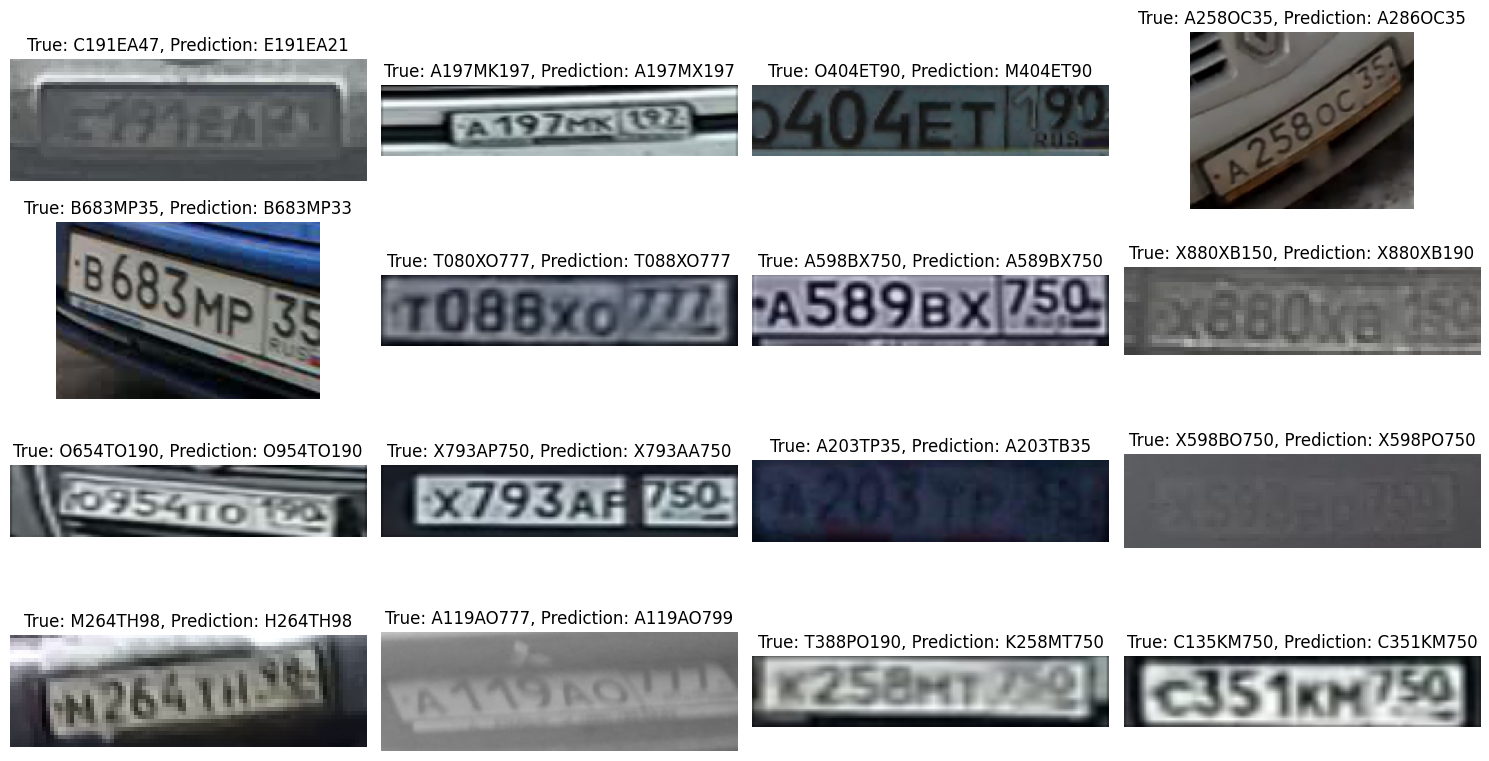

In [ ]:
NUM_COLS = 4
SAMPLE_SIZE = NUM_COLS ** 2
NUM_ROWS = SAMPLE_SIZE // NUM_COLS + int(SAMPLE_SIZE % NUM_COLS != 0)

random_idxs = np.random.choice(
    len(errors),
    size=SAMPLE_SIZE,
    replace=False
)
plt.figure(figsize=(15, 2 * NUM_ROWS))
for i, idx in enumerate(random_idxs, 1):
    row = errors.loc[idx]
    true_text = row['target']
    pred_text = row['predictions']
    image = row['target_image']

    plt.subplot(NUM_ROWS, NUM_COLS, i)
    plt.imshow(image)
    plt.title(f'True: {true_text}, Prediction: {pred_text}')
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def get_submission(test_dataloader, best_model):
    predicts = []
    for i, b in enumerate(tqdm.tqdm(test_dataloader, total=len(test_dataloader))):
        images      = b["torch_images"].to(device)
        seqs_gt     = b["seq"]
        seq_lens_gt = b["seq_len"]
        with torch.no_grad():
            seqs_pred = best_model(images).cpu()
        predicts.append(decode(seqs_pred, abc))

    predictions = flatten(predicts)
    return predictions



In [ ]:
def clean_predictions(predictions):
    cleaned_predictions = []
    for i in predictions:
        if len(i)>=10:
            cleaned = i[:9]
        else:
            cleaned = i
        if len(cleaned) == 7:
            left = cleaned[:3]
            miss = left[-1]
            right = cleaned[3:]
            cleaned = left+miss+right


        cleaned_predictions.append(cleaned)
    return cleaned_predictions

In [ ]:
predictions = get_submission(test_dataloader, best_model)
#predictions = clean_predictions(predictions)
submission = pd.DataFrame(predictions).reset_index().rename(columns={0: "label"}).to_csv("output/submission.csv", index=False)



100%|██████████████████████████████████████████████████████████████████████████████████████| 83/83 [01:15<00:00,  1.10it/s]
